# RetailPulse - Day 11

## Feature Importance Analysis and Model Tuning with Optuna

Objective:
Use Optuna to tune the XGBoost churn model from Day 9 for better AUC-ROC, and analyze feature importance using both XGBoost's built-in importance and SHAP.

In [1]:
pip install optuna

  Using cached colorlog-6.10.1-py3-none-any.whl.metadata (11 kB)
Using cached colorlog-6.10.1-py3-none-any.whl (11 kB)

   -------------------- ------------------- 1/2 [optuna]
   -------------------- ------------------- 1/2 [optuna]
   -------------------- ------------------- 1/2 [optuna]
   -------------------- ------------------- 1/2 [optuna]
   ---------------------------------------- 2/2 [optuna]

Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix, roc_curve

from imblearn.over_sampling import SMOTE

import xgboost as xgb

import shap

import optuna

## Step 1: Load Churn Data from Day 9

In [3]:
churn_data = pd.read_csv("../data/churn_predictions.csv")

print(churn_data.shape)

churn_data.head()

(4338, 13)


,Customer ID,Recency,Frequency,Monetary,Cluster,Segment,Churn,AvgOrderValue,UniqueProducts,TotalQuantity,AvgCustomerFrequency,ChurnProbability,PredictedChurn
0,12346.0,326,1,77183.60,1,VIP,1,77183.600000,1,74215,1.0,0.998759,1
1,12347.0,2,182,4310.00,0,Regular,0,23.681319,103,2458,182.0,0.000351,0
2,12348.0,75,31,1797.24,0,Regular,0,57.975484,22,2341,31.0,0.000552,0
3,12349.0,19,73,1757.55,0,Regular,0,24.076027,73,631,73.0,0.001358,0
4,12350.0,310,17,334.40,1,VIP,1,19.670588,17,197,17.0,0.999375,1


In [4]:
feature_cols = [
    "Recency",
    "Frequency",
    "Monetary",
    "AvgOrderValue",
    "UniqueProducts",
    "TotalQuantity",
    "AvgCustomerFrequency"
]

X = churn_data[feature_cols].fillna(0)
y = churn_data["Churn"]

print(X.shape)
print(y.value_counts())

(4338, 7)
Churn
0    3254
1    1084
Name: count, dtype: int64


## Step 2: Train-Test Split + SMOTE

Same setup as Day 9 - SMOTE applied only to training data.

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

smote = SMOTE(random_state=42)

X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print(X_train_res.shape)
print(y_train_res.value_counts())

(5206, 7)
Churn
0    2603
1    2603
Name: count, dtype: int64


## Step 3: Baseline AUC (Day 9 Configuration)

Re-establish the baseline AUC with the original Day 9 hyperparameters before tuning.

In [6]:
baseline_model = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="auc",
    random_state=42
)

baseline_model.fit(X_train_res, y_train_res)

baseline_proba = baseline_model.predict_proba(X_test)[:,1]

baseline_auc = roc_auc_score(y_test, baseline_proba)

print("Baseline AUC-ROC (Day 9):", baseline_auc)

Baseline AUC-ROC (Day 9): 1.0


## Step 4: Define Optuna Objective Function

We use 5-fold stratified cross-validation on the SMOTE-resampled training data to evaluate each set of hyperparameters by mean AUC-ROC.

In [7]:
def objective(trial):

    params = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 500),
        "max_depth": trial.suggest_int("max_depth", 3, 10),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
        "gamma": trial.suggest_float("gamma", 0, 5),
        "reg_alpha": trial.suggest_float("reg_alpha", 0, 5),
        "reg_lambda": trial.suggest_float("reg_lambda", 0, 5),
        "eval_metric": "auc",
        "random_state": 42
    }

    model = xgb.XGBClassifier(**params)

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    scores = cross_val_score(
        model,
        X_train_res,
        y_train_res,
        cv=cv,
        scoring="roc_auc"
    )

    return scores.mean()

## Step 5: Run Optuna Study

In [8]:
study = optuna.create_study(direction="maximize")

study.optimize(objective, n_trials=30, show_progress_bar=True)

print("Best CV AUC:", study.best_value)
print("Best Params:", study.best_params)

[I 2026-06-12 14:34:50,597] A new study created in memory with name: no-name-9a741641-e375-4c22-882c-4487020db611


  0%|          | 0/30 [00:00<?, ?it/s]

[I 2026-06-12 14:34:51,391] Trial 0 finished with value: 0.9999985235493873 and parameters: {'n_estimators': 205, 'max_depth': 7, 'learning_rate': 0.07513147580111235, 'subsample': 0.9292034554126183, 'colsample_bytree': 0.9965590731671405, 'min_child_weight': 2, 'gamma': 2.5721592516546354, 'reg_alpha': 2.271039253886552, 'reg_lambda': 3.7607867972883553}. Best is trial 0 with value: 0.9999985235493873.
[I 2026-06-12 14:34:53,082] Trial 1 finished with value: 0.9999985235493873 and parameters: {'n_estimators': 467, 'max_depth': 9, 'learning_rate': 0.022775215410898872, 'subsample': 0.7296928858769208, 'colsample_bytree': 0.87537651209841, 'min_child_weight': 10, 'gamma': 0.8388489932581888, 'reg_alpha': 4.8689619110601505, 'reg_lambda': 3.00080177620649}. Best is trial 0 with value: 0.9999985235493873.
[I 2026-06-12 14:34:54,564] Trial 2 finished with value: 0.9999992617746937 and parameters: {'n_estimators': 454, 'max_depth': 10, 'learning_rate': 0.07376775607720602, 'subsample': 0.8

## Step 6: Optuna Optimization History

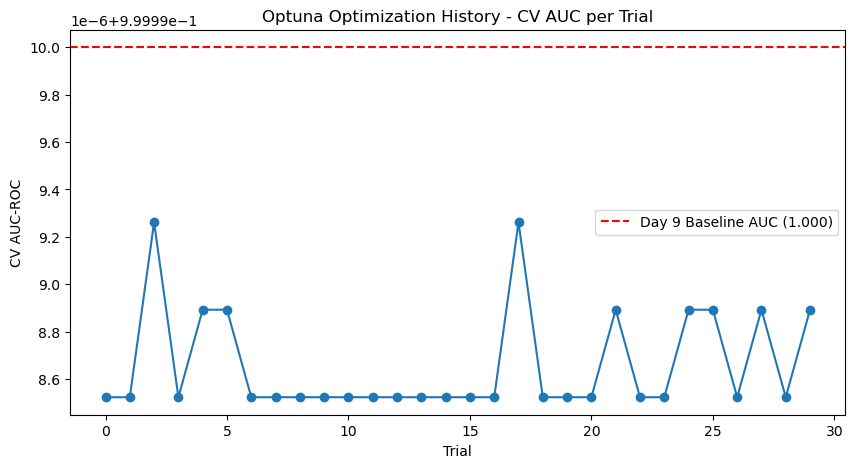

In [9]:
trials_df = study.trials_dataframe()

plt.figure(figsize=(10,5))

plt.plot(trials_df["number"], trials_df["value"], marker="o")

plt.axhline(baseline_auc, color="red", linestyle="--", label=f"Day 9 Baseline AUC ({baseline_auc:.3f})")

plt.title("Optuna Optimization History - CV AUC per Trial")

plt.xlabel("Trial")
plt.ylabel("CV AUC-ROC")

plt.legend()

plt.show()

## Step 7: Train Final Tuned Model

In [10]:
best_params = study.best_params

best_params["eval_metric"] = "auc"
best_params["random_state"] = 42

tuned_model = xgb.XGBClassifier(**best_params)

tuned_model.fit(X_train_res, y_train_res)

tuned_proba = tuned_model.predict_proba(X_test)[:,1]

tuned_pred = tuned_model.predict(X_test)

tuned_auc = roc_auc_score(y_test, tuned_proba)

print("Tuned Test AUC-ROC:", tuned_auc)
print("Baseline Test AUC-ROC:", baseline_auc)

Tuned Test AUC-ROC: 0.9999575272356601
Baseline Test AUC-ROC: 1.0


## Step 8: Compare Baseline vs Tuned Model

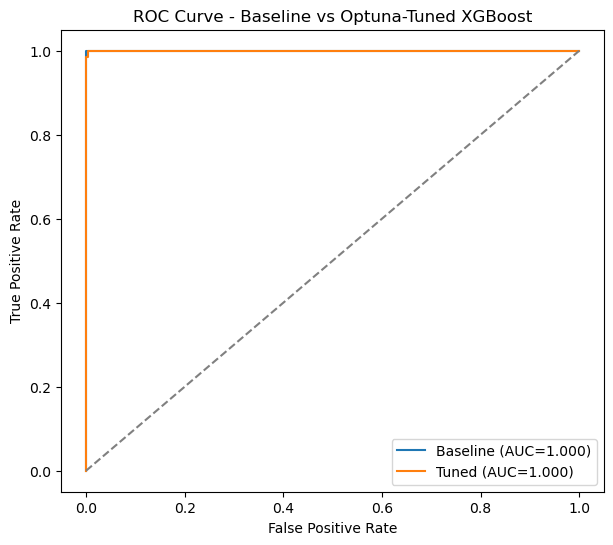

In [11]:
fpr_base, tpr_base, _ = roc_curve(y_test, baseline_proba)
fpr_tuned, tpr_tuned, _ = roc_curve(y_test, tuned_proba)

plt.figure(figsize=(7,6))

plt.plot(fpr_base, tpr_base, label=f"Baseline (AUC={baseline_auc:.3f})")
plt.plot(fpr_tuned, tpr_tuned, label=f"Tuned (AUC={tuned_auc:.3f})")

plt.plot([0,1],[0,1], linestyle="--", color="gray")

plt.title("ROC Curve - Baseline vs Optuna-Tuned XGBoost")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.legend()

plt.show()

In [12]:
print("Tuned Model Classification Report:")
print(classification_report(y_test, tuned_pred))

Tuned Model Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       651
           1       0.99      0.99      0.99       217

    accuracy                           1.00       868
   macro avg       0.99      0.99      0.99       868
weighted avg       1.00      1.00      1.00       868



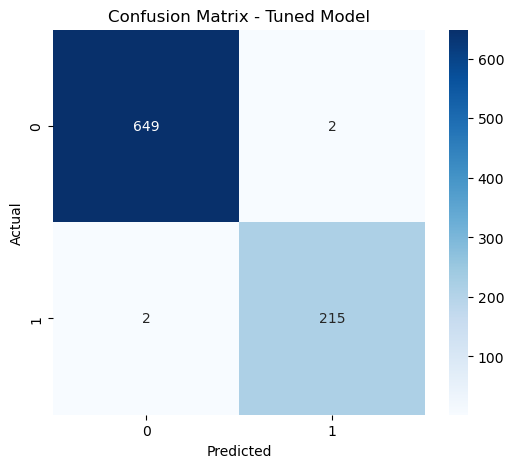

In [13]:
cm = confusion_matrix(y_test, tuned_pred)

plt.figure(figsize=(6,5))

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.title("Confusion Matrix - Tuned Model")

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

## Step 9: Precision @ Top 20% - Tuned Model

In [14]:
eval_df = pd.DataFrame({
    "actual": y_test.values,
    "proba": tuned_proba
})

eval_df = eval_df.sort_values("proba", ascending=False).reset_index(drop=True)

top_20_pct = int(len(eval_df) * 0.2)

precision_top20 = eval_df.head(top_20_pct)["actual"].mean()

print("Precision@Top20% (Tuned):", precision_top20)

Precision@Top20% (Tuned): 1.0


## Step 10: Feature Importance - XGBoost Built-in

C:\Users\khush\AppData\Local\Temp\ipykernel_6492\136522722.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importance, x="Importance", y="Feature", palette="viridis")


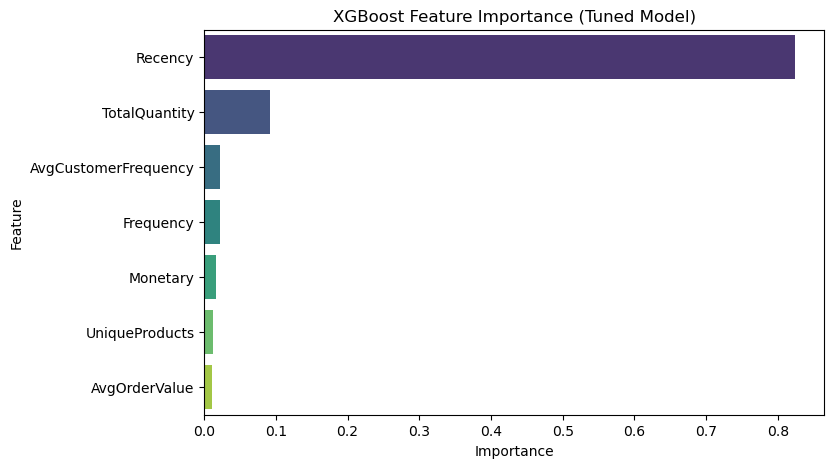

,Feature,Importance
0,Recency,0.823380
5,TotalQuantity,0.092206
6,AvgCustomerFrequency,0.022462
1,Frequency,0.021489
2,Monetary,0.016979
4,UniqueProducts,0.012976
3,AvgOrderValue,0.010507


In [15]:
importance = pd.DataFrame({
    "Feature": feature_cols,
    "Importance": tuned_model.feature_importances_
}).sort_values("Importance", ascending=False)

plt.figure(figsize=(8,5))

sns.barplot(data=importance, x="Importance", y="Feature", palette="viridis")

plt.title("XGBoost Feature Importance (Tuned Model)")

plt.show()

importance

## Step 11: SHAP Feature Importance - Tuned Model

In [16]:
explainer = shap.TreeExplainer(tuned_model)

shap_values = explainer.shap_values(X_test)

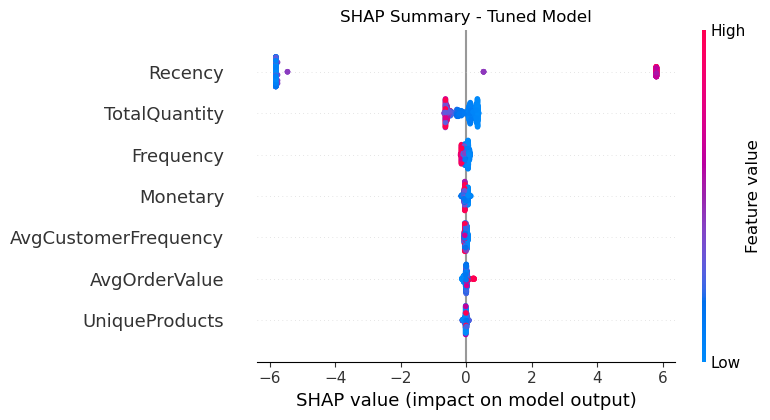

In [17]:
shap.summary_plot(shap_values, X_test, show=False)

plt.title("SHAP Summary - Tuned Model")

plt.tight_layout()

plt.show()

## Step 12: Save Tuned Model and Results

In [18]:
import os

os.makedirs("../models", exist_ok=True)

tuned_model.save_model("../models/xgb_churn_model_tuned.json")

print("Tuned model saved")

Tuned model saved


In [19]:
full_proba_tuned = tuned_model.predict_proba(X)[:,1]

churn_results_tuned = churn_data.copy()

churn_results_tuned["ChurnProbability_Tuned"] = full_proba_tuned

churn_results_tuned["PredictedChurn_Tuned"] = (churn_results_tuned["ChurnProbability_Tuned"] >= 0.5).astype(int)

churn_results_tuned.to_csv("../data/churn_predictions_tuned.csv", index=False)

print("Tuned churn predictions saved")

Tuned churn predictions saved


In [20]:
tuning_summary = pd.DataFrame({
    "Metric": [
        "Baseline AUC-ROC",
        "Tuned AUC-ROC",
        "Improvement",
        "Precision@Top20% (Tuned)",
        "Best CV AUC (Optuna)",
        "Number of Trials"
    ],
    "Value": [
        baseline_auc,
        tuned_auc,
        tuned_auc - baseline_auc,
        precision_top20,
        study.best_value,
        len(study.trials)
    ]
})

best_params_df = pd.DataFrame(
    list(study.best_params.items()),
    columns=["Parameter","Value"]
)

tuning_summary.to_csv("../data/optuna_tuning_summary.csv", index=False)

best_params_df.to_csv("../data/optuna_best_params.csv", index=False)

print("Tuning summary saved")

tuning_summary

Tuning summary saved


,Metric,Value
0,Baseline AUC-ROC,1.000000
1,Tuned AUC-ROC,0.999958
2,Improvement,-0.000042
3,Precision@Top20% (Tuned),1.000000
4,Best CV AUC (Optuna),0.999999
5,Number of Trials,30.000000


# Day 11 Findings

1. Re-established the Day 9 baseline AUC-ROC on the same train/test/SMOTE split.
2. Defined an Optuna objective using 5-fold stratified cross-validation on SMOTE-resampled training data, tuning n_estimators, max_depth, learning_rate, subsample, colsample_bytree, min_child_weight, gamma, reg_alpha, and reg_lambda.
3. Ran 30 Optuna trials and tracked CV AUC improvement over the baseline.
4. Trained a final tuned XGBoost model with the best hyperparameters and compared ROC curves and classification metrics against the baseline.
5. Recomputed Precision@Top20% for the tuned model.
6. Analyzed feature importance using both XGBoost's built-in importance and SHAP for the tuned model.
7. Saved the tuned model, updated churn predictions, best hyperparameters, and a tuning summary for documentation.